In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


In [3]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

In [4]:

BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

features_path = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
classes_path  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
edges_path    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

features_df = pd.read_csv(features_path, header=None)
classes_df  = pd.read_csv(classes_path)
edges_df    = pd.read_csv(edges_path)

print(features_df.shape)
print(classes_df.shape)
print(edges_df.shape)

(203769, 167)
(203769, 2)
(234355, 2)


In [5]:
# =========================================================
# 2. RENAME COLUMNS
# =========================================================

feature_cols = ["txId", "time_step"] + [f"feature_{i}" for i in range(1, features_df.shape[1] - 1)]
features_df.columns = feature_cols

classes_df.columns = ["txId", "class"]
edges_df.columns = ["txId1", "txId2"]

features_df.head()

# =========================================================
# 3. MERGE FEATURES + LABELS
# =========================================================

df = features_df.merge(classes_df, on="txId", how="left")

df["class_name"] = df["class"].map({
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
})

df.head()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,class_name
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.03

In [6]:
# =========================================================
# 4. BASIC DATA OVERVIEW
# =========================================================

print("Rows, Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nClass counts:")
print(df["class_name"].value_counts(dropna=False))

print("\nTime steps:")
print(df["time_step"].min(), "to", df["time_step"].max())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(20))

Rows, Columns: (203769, 169)

Columns:
['txId', 'time_step', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_6

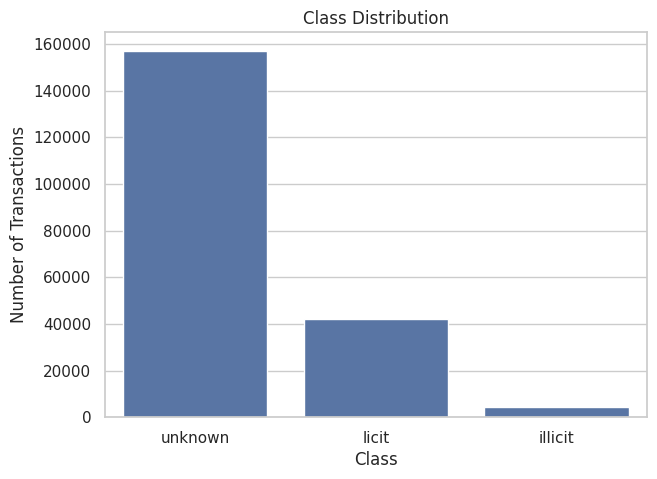

class_name
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

In [7]:
# =========================================================
# 5. CLASS DISTRIBUTION
# =========================================================

class_counts = df["class_name"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

class_counts

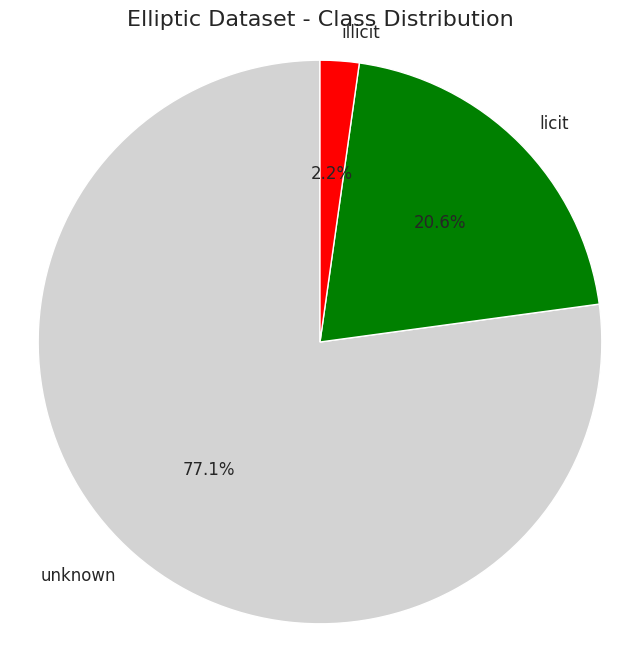

In [32]:
# =========================================================
# PIE CHART - CLASS DISTRIBUTION
# =========================================================

class_counts = df["class_name"].value_counts()

labels = class_counts.index
sizes = class_counts.values

colors = [
    "lightgray" if l == "unknown" else
    "green" if l == "licit" else
    "red"
    for l in labels
]

plt.figure(figsize=(8, 8))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12}
)

plt.title("Elliptic Dataset - Class Distribution", fontsize=16)

plt.axis("equal")  # giữ hình tròn đẹp
plt.show()

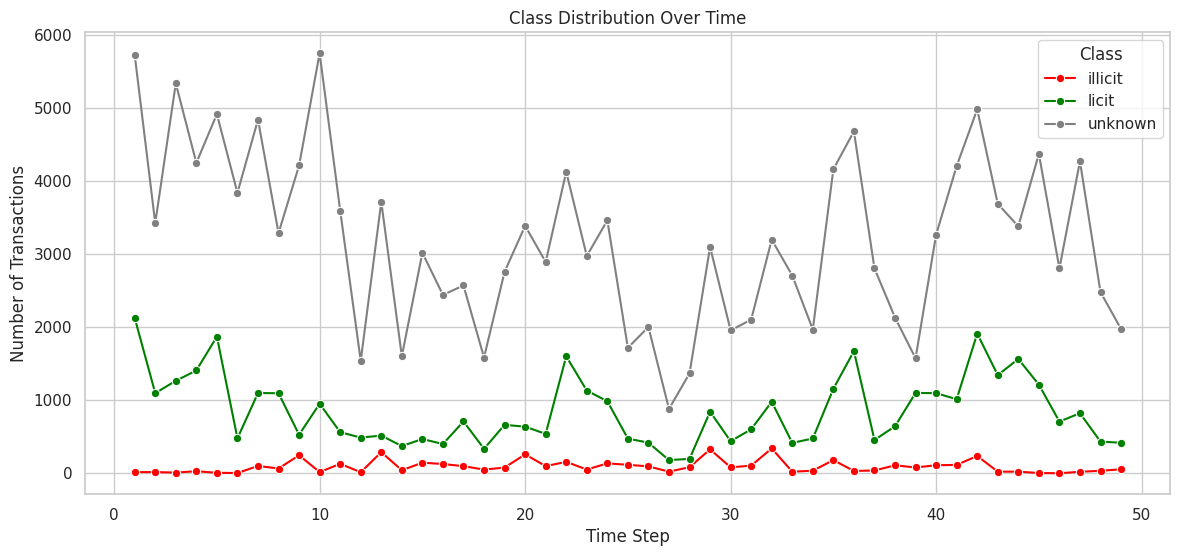

In [9]:
# =========================================================
# 6. CLASS DISTRIBUTION BY TIME STEP (CUSTOM COLORS)
# =========================================================

class_by_time = (
    df.groupby(["time_step", "class_name"])
      .size()
      .reset_index(name="count")
)

palette = {
    "unknown": "gray",
    "licit": "green",
    "illicit": "red"
}

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=class_by_time,
    x="time_step",
    y="count",
    hue="class_name",
    palette=palette,
    marker="o"
)

plt.title("Class Distribution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.legend(title="Class")
plt.show()

In [16]:
# =========================================================
# 13. BUILD GRAPH
# =========================================================

G = nx.from_pandas_edgelist(
    edges_df,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed:", G.is_directed())
print("Is DAG:", nx.is_directed_acyclic_graph(G))

Number of nodes: 203769
Number of edges: 234355
Is directed: True
Is DAG: True


In [17]:
# =========================================================
# 14. BASIC DEGREE FEATURES
# =========================================================

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
total_degree = dict(G.degree())

degree_df = pd.DataFrame({
    "txId": list(G.nodes()),
    "in_degree": [in_degree[n] for n in G.nodes()],
    "out_degree": [out_degree[n] for n in G.nodes()],
    "total_degree": [total_degree[n] for n in G.nodes()]
})

df_graph = df.merge(degree_df, on="txId", how="left")

df_graph[["in_degree", "out_degree", "total_degree"]] = df_graph[
    ["in_degree", "out_degree", "total_degree"]
].fillna(0)

df_graph.head()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,class_name,label_status,in_degree,out_degree,total_degree
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,unknown,unknown,1,1,2
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0

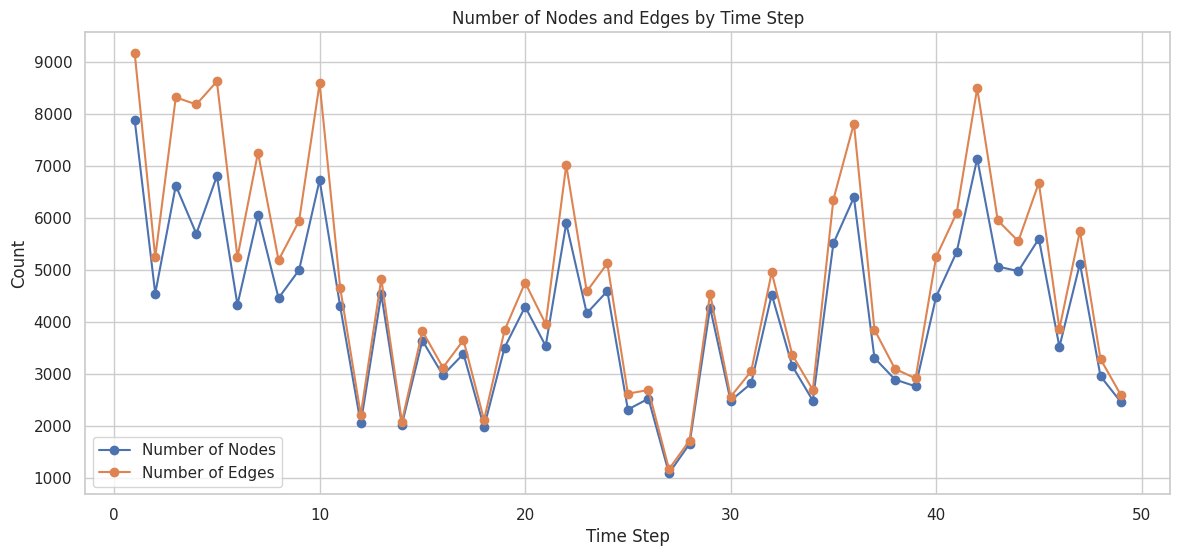

In [28]:
# =========================================================
# NODE & EDGE COUNT BY TIME STEP
# =========================================================

records = []

for t in sorted(df["time_step"].unique()):
    nodes_t = df.loc[df["time_step"] == t, "txId"].tolist()
    
    # subgraph theo timestep
    G_t = G.subgraph(nodes_t)
    
    records.append({
        "time_step": t,
        "num_nodes": G_t.number_of_nodes(),
        "num_edges": G_t.number_of_edges()
    })

time_graph_df = pd.DataFrame(records)

plt.figure(figsize=(14, 6))

plt.plot(
    time_graph_df["time_step"],
    time_graph_df["num_nodes"],
    marker="o",
    label="Number of Nodes"
)

plt.plot(
    time_graph_df["time_step"],
    time_graph_df["num_edges"],
    marker="o",
    label="Number of Edges"
)

plt.title("Number of Nodes and Edges by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Count")
plt.legend()
plt.show()

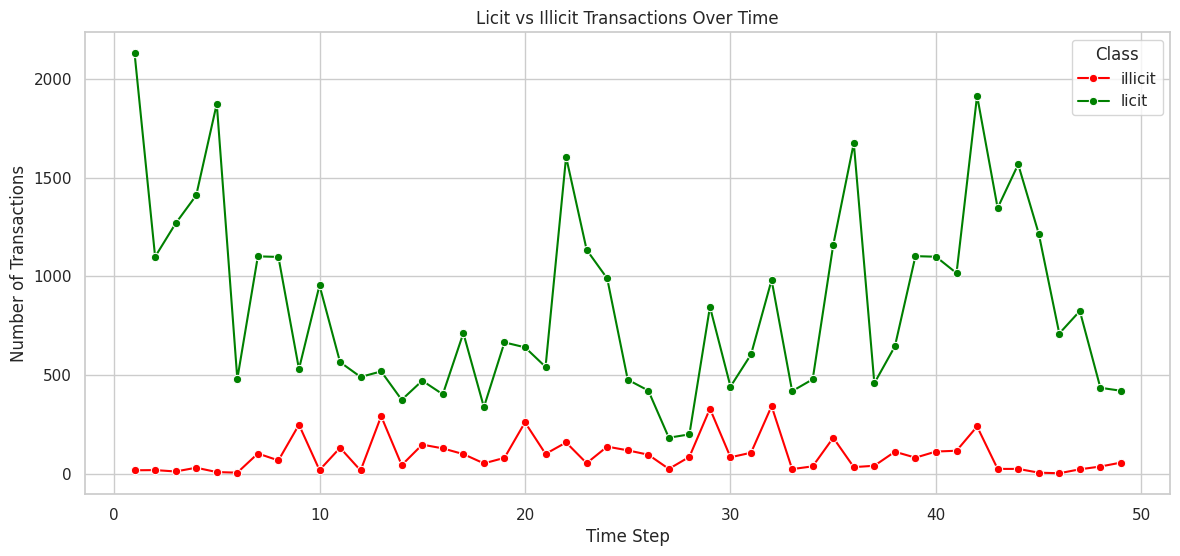

In [30]:
# =========================================================
# LICIT VS ILLICIT BY TIME STEP (LINE PLOT)
# =========================================================

labeled_df = df[df["class_name"].isin(["licit", "illicit"])]

class_by_time = (
    labeled_df.groupby(["time_step", "class_name"])
    .size()
    .reset_index(name="count")
)

palette = {
    "licit": "green",
    "illicit": "red"
}

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=class_by_time,
    x="time_step",
    y="count",
    hue="class_name",
    palette=palette,
    marker="o"
)

plt.title("Licit vs Illicit Transactions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.legend(title="Class")
plt.show()